In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [20]:
DATA_PATH = Path("../data/processed/crop_recommendation_clean.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [21]:
df.shape

(2200, 8)

In [22]:
target_col = "label"
feature_cols = df.drop(columns=target_col).columns.tolist()

feature_cols

['n', 'p', 'k', 'temperature', 'humidity', 'ph', 'rainfall']

In [23]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [24]:
crop_counts = df[target_col].value_counts().sort_index()

crop_counts

label
apple          100
banana         100
blackgram      100
chickpea       100
coconut        100
coffee         100
cotton         100
grapes         100
jute           100
kidneybeans    100
lentil         100
maize          100
mango          100
mothbeans      100
mungbean       100
muskmelon      100
orange         100
papaya         100
pigeonpeas     100
pomegranate    100
rice           100
watermelon     100
Name: count, dtype: int64

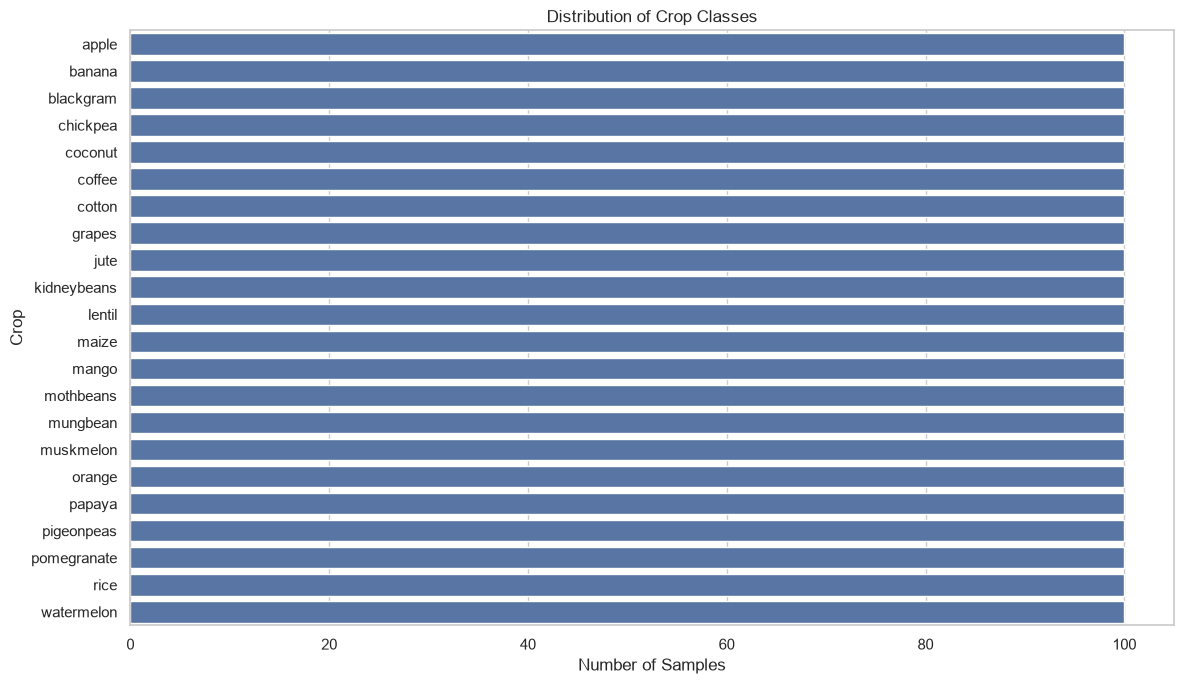

In [25]:
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df,
    y=target_col,
    order=crop_counts.index
)
plt.title("Distribution of Crop Classes")
plt.xlabel("Number of Samples")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

The dataset is perfectly balanced, with 100 observations for each of the 22 crop classes. This reduces the risk of class imbalance and makes macro-F1 and accuracy both meaningful evaluation metrics. However, macro-F1 will remain the primary metrics because it treats all crops equally.

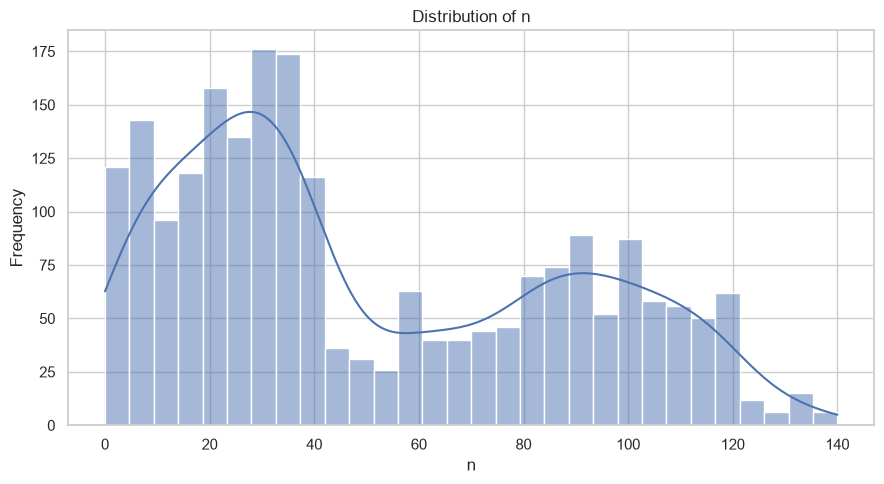

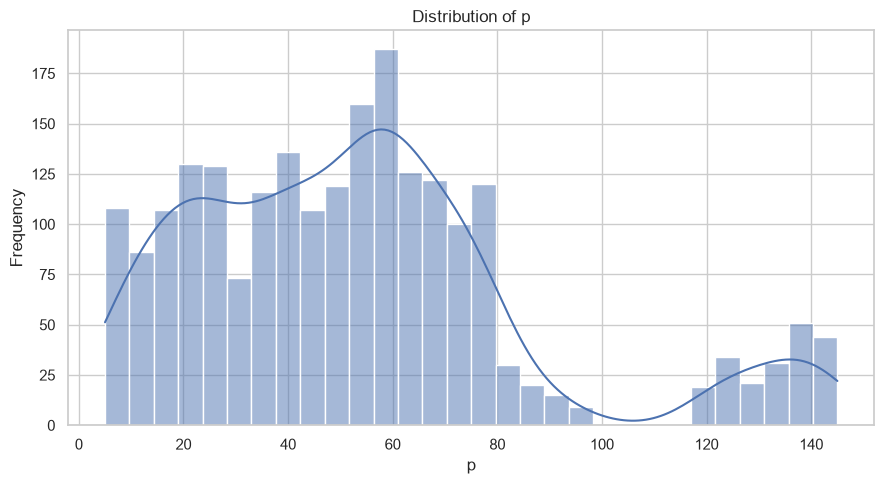

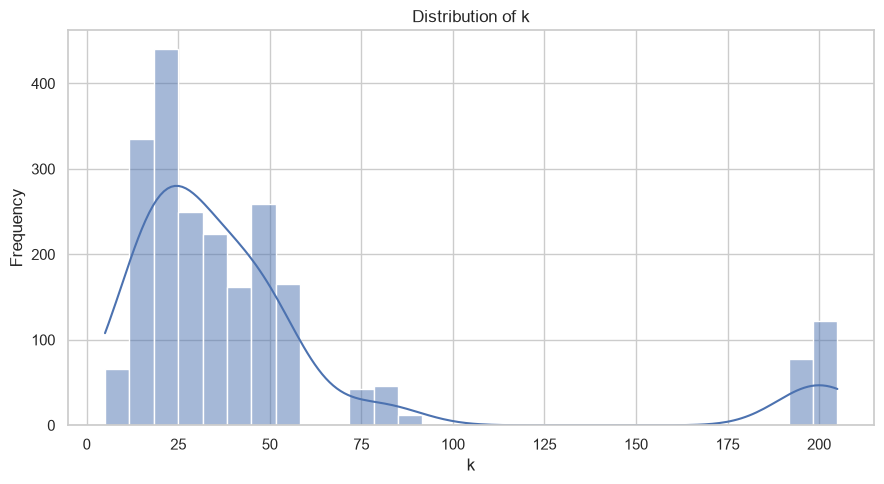

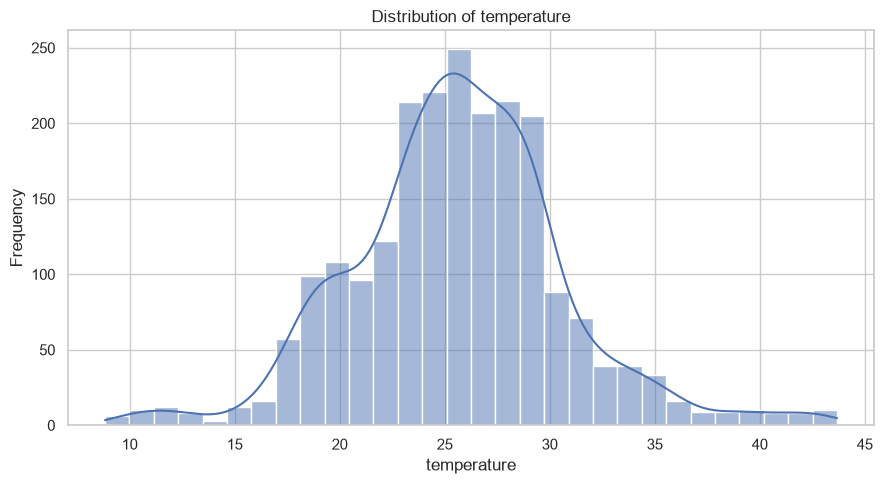

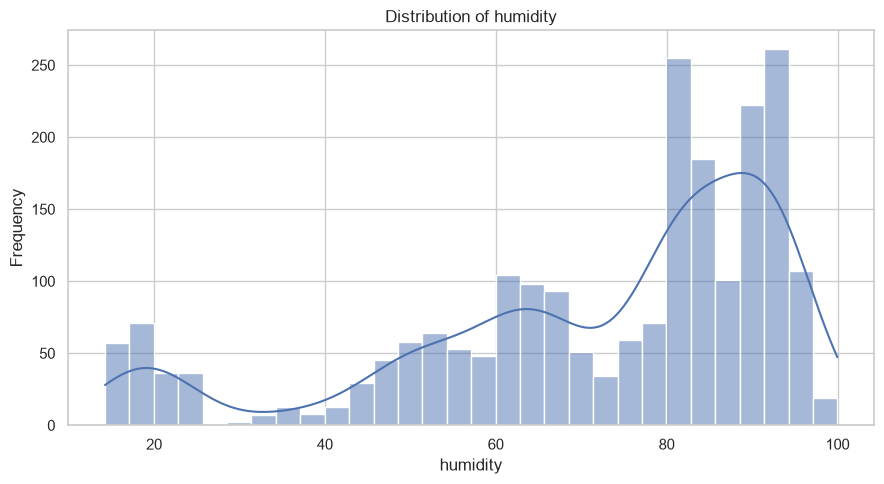

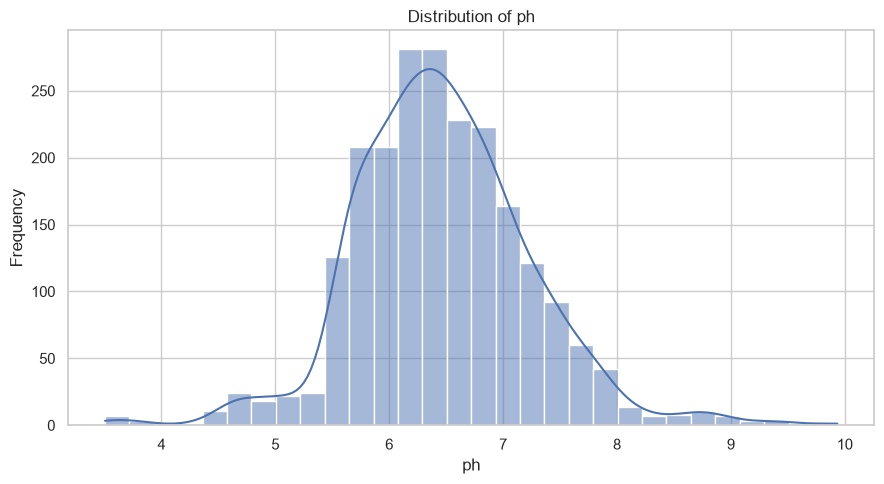

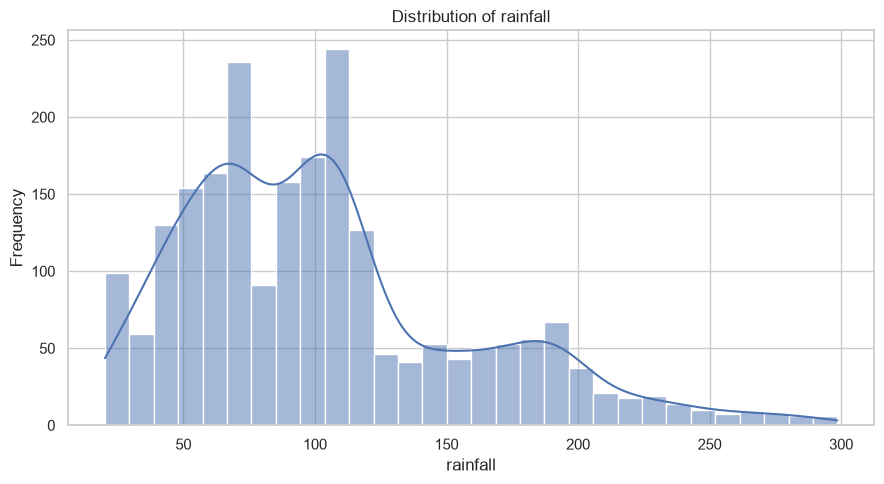

In [26]:
for col in feature_cols:
    plt.figure(figsize=(9, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


The features have different distributions and scales. Rainfall and nutrient values cover wider numeric ranges than pH. This confirms that scaling will be useful for scale-sensitive models such as Logistic Regression, KNN, and SVM.

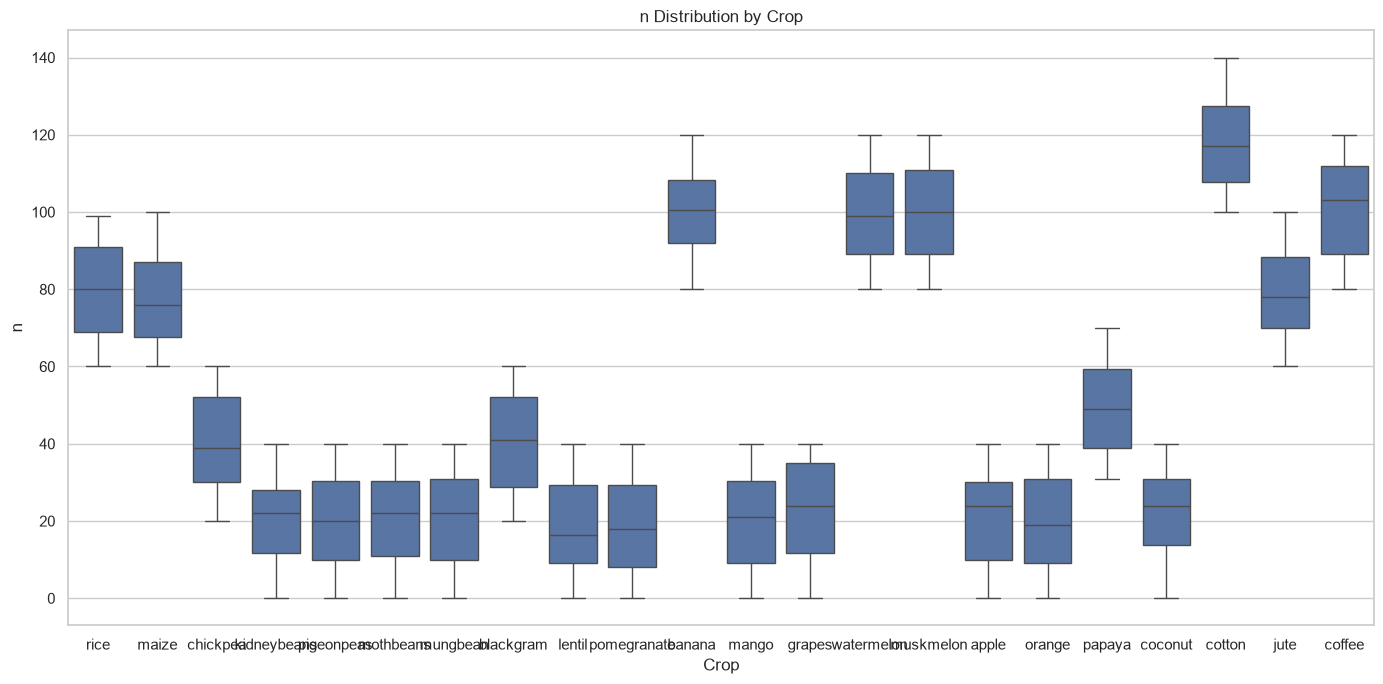

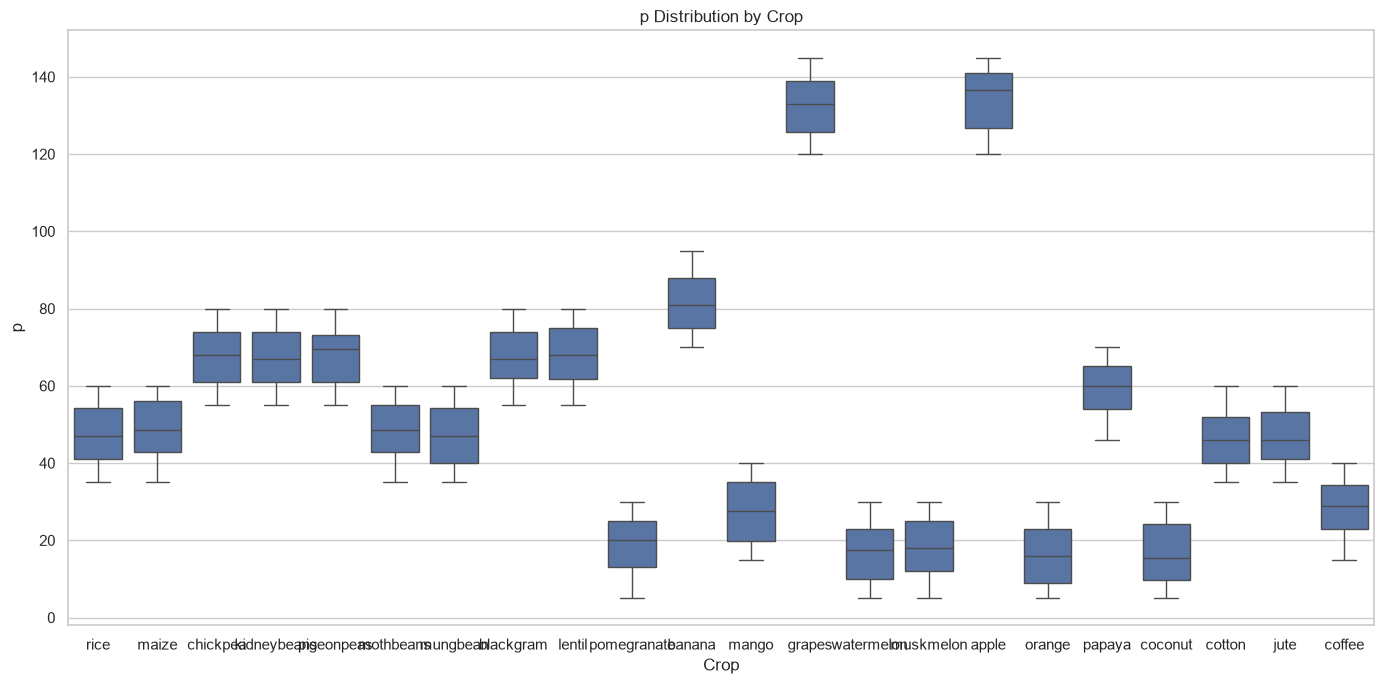

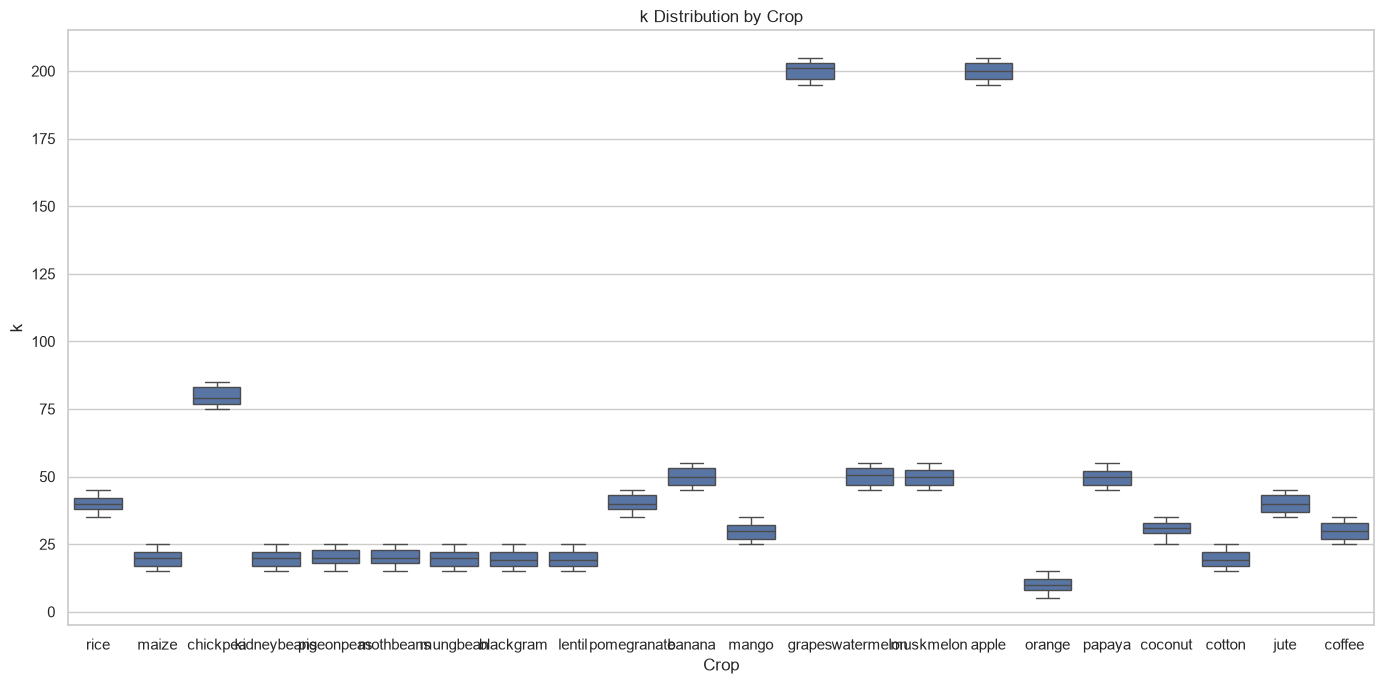

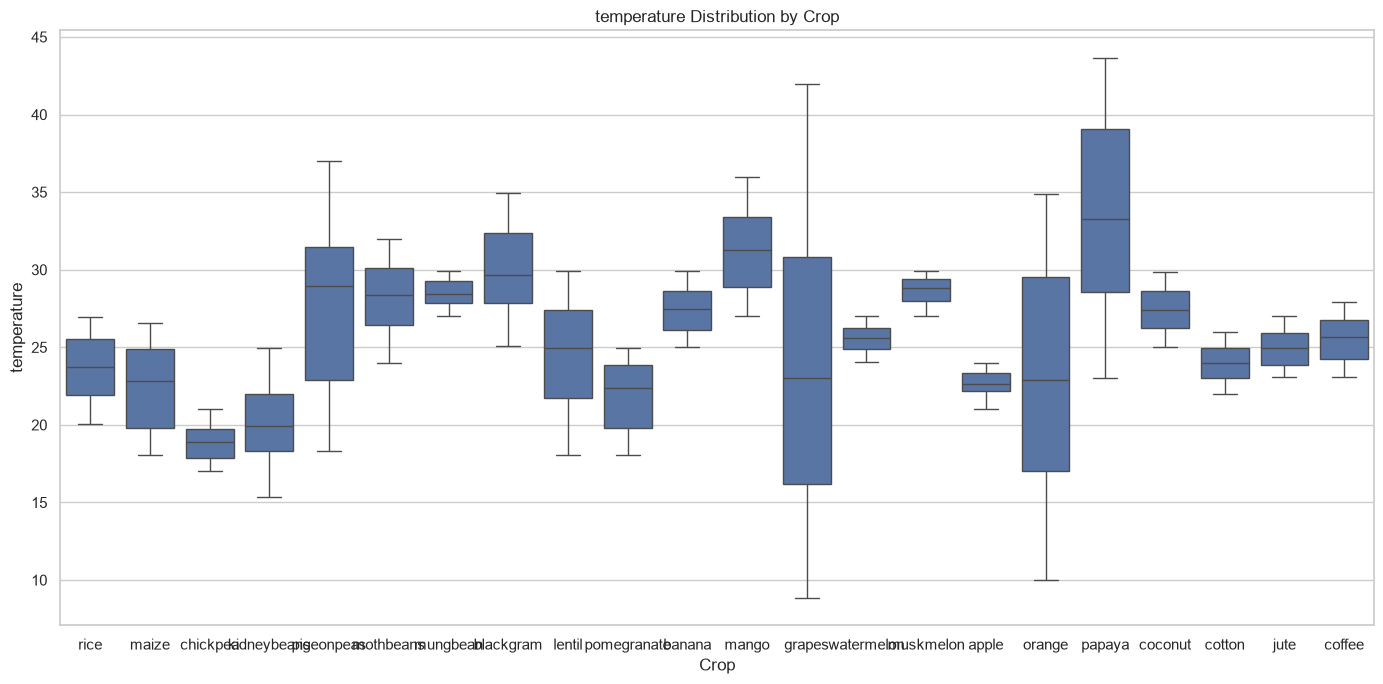

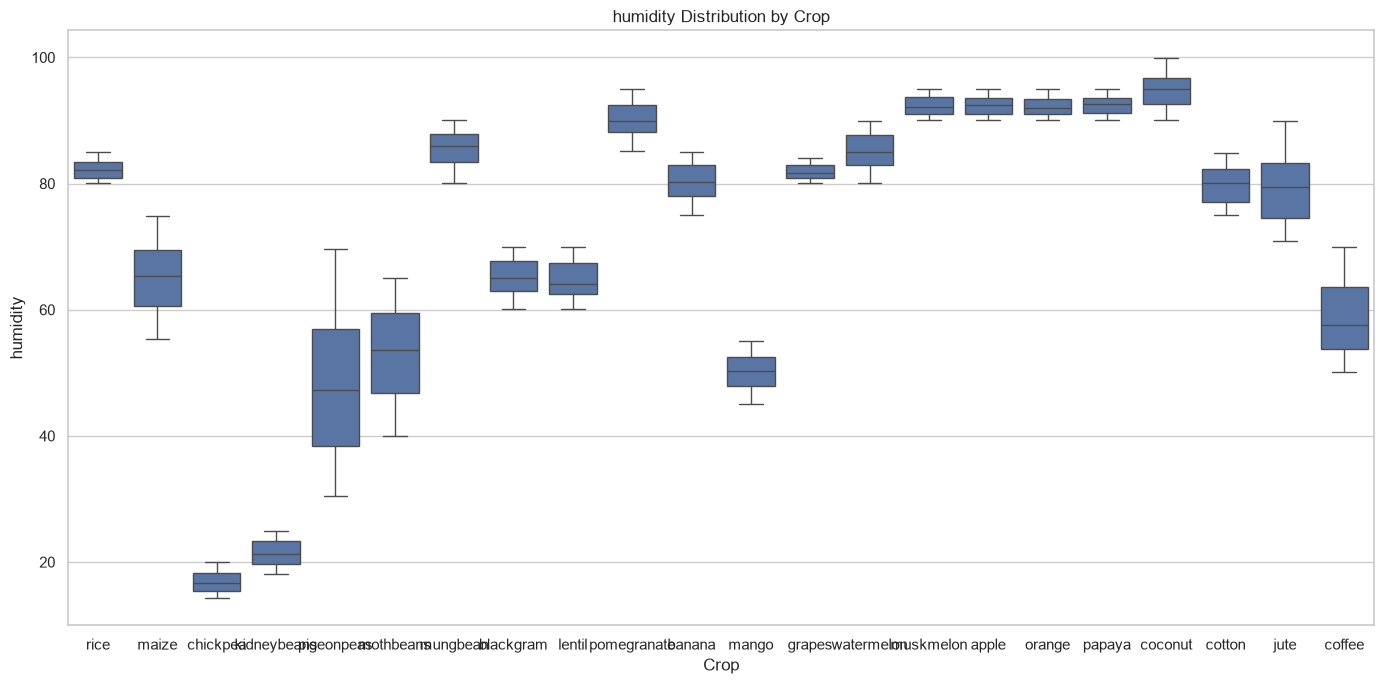

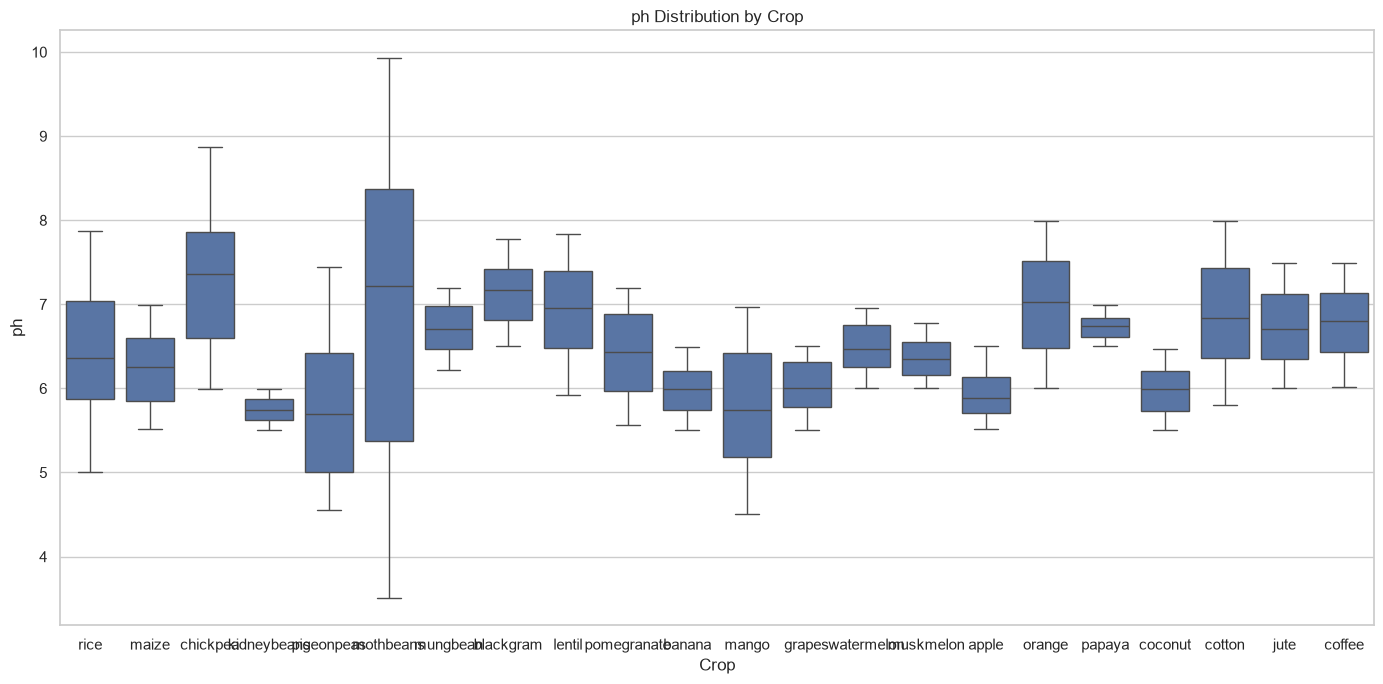

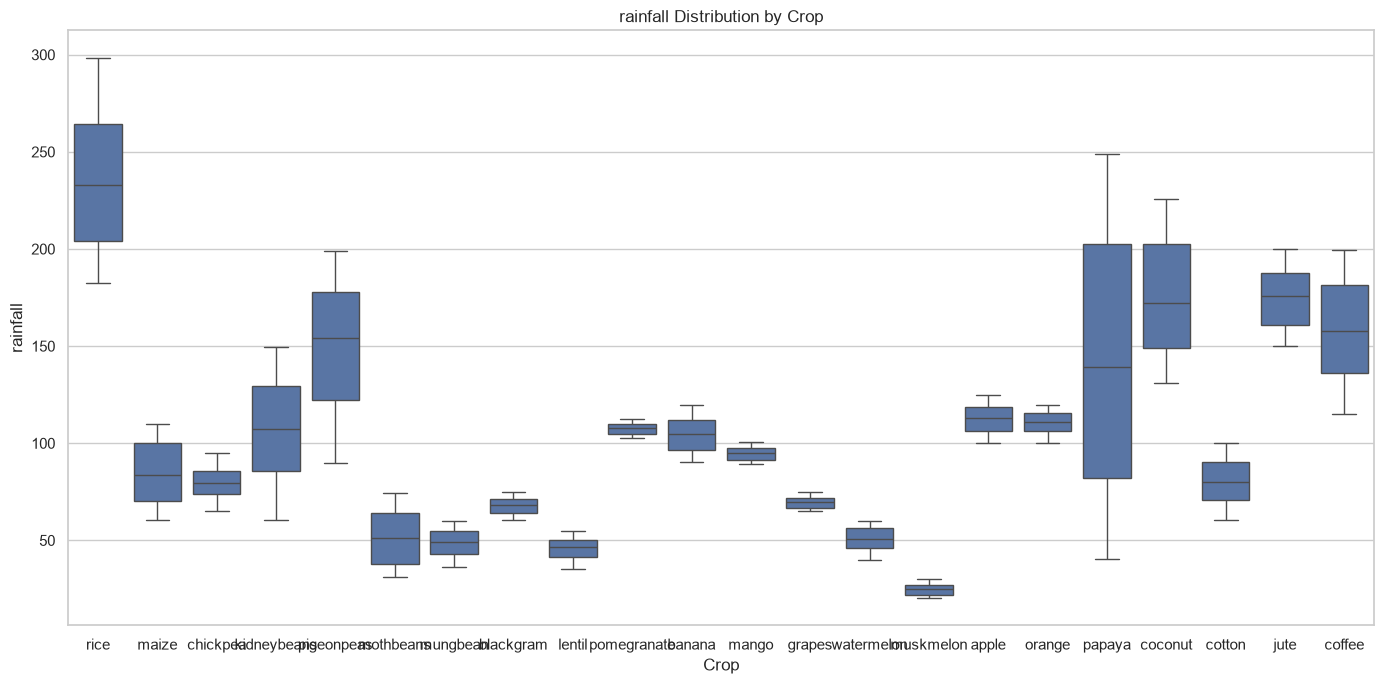

In [27]:
for col in feature_cols:
    plt.figure(figsize=(14, 7))
    sns.boxplot(
        data=df,
        x=target_col,
        y=col
    )
    plt.title(f"{col} Distribution by Crop")
    plt.xlabel("Crop")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

The crop-wise boxplots show that many crops occupy distinct ranges for soil nutrients and climate conditions. this suggests  that the features contain meaningful signal for crop classification.

In [28]:
crop_feature_means = df.groupby(target_col)[feature_cols].mean().round(2)

crop_feature_means

,n,p,k,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69
coffee,101.20,28.74,29.94,25.54,58.87,6.79,158.07
cotton,117.77,46.24,19.56,23.99,79.84,6.91,80.40
grapes,23.18,132.53,200.11,23.85,81.88,6.03,69.61
jute,78.40,46.86,39.99,24.96,79.64,6.73,174.79


Crop-wise mean feature values provide an interpretable agronomic profile for each crop. For example, crops with high average rainfall requirements can be identified and compared against crops that appear in lower-rainfall conditions.

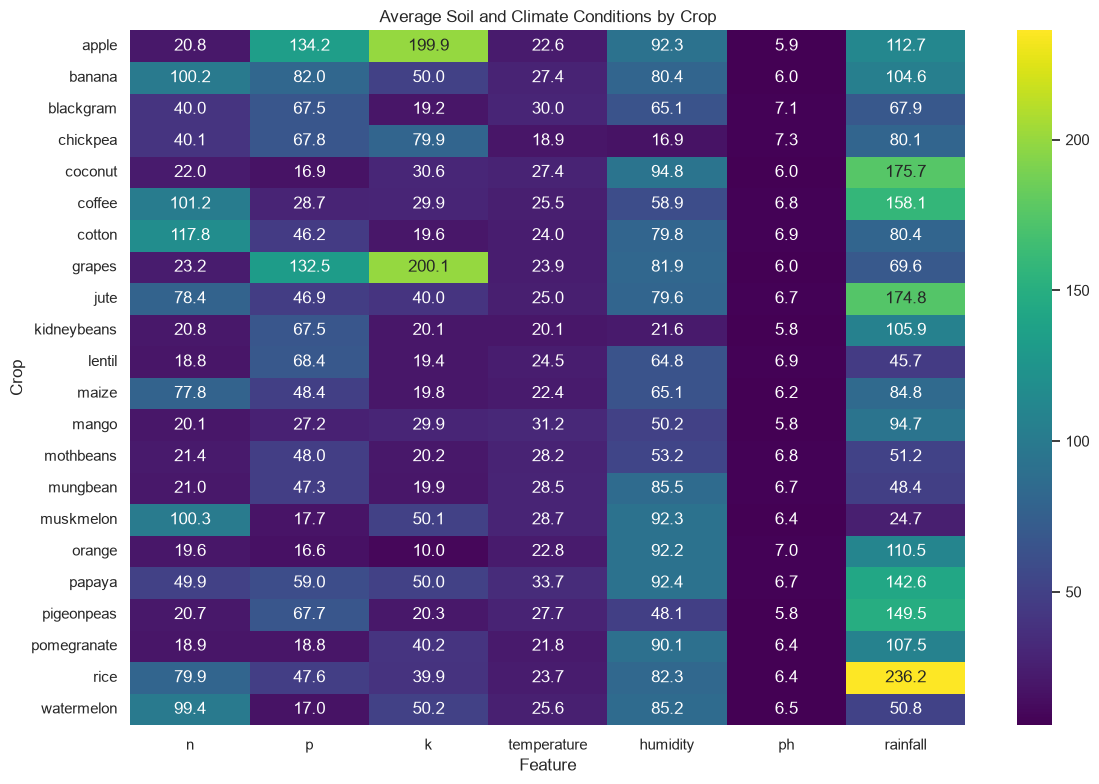

In [29]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    crop_feature_means,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)
plt.title("Average Soil and Climate Conditions by Crop")
plt.xlabel("Feature")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

The heatmap highlights how different crops are associated with different soil and climate profiles. Some crops ar characterized by high rainfall and humidity, while other are more associated with specific nutrient patterns.

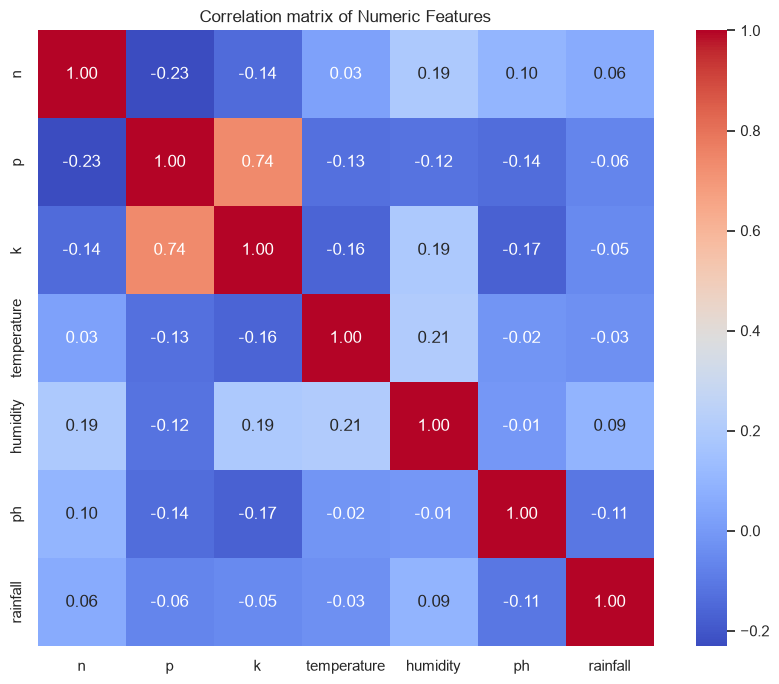

In [30]:
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Correlation matrix of Numeric Features")
plt.tight_layout()
plt.show()

The correlation matrix helps identify relationships among predictor variables. Strong correlations may suggest redundancy, while weak correlations indicate that features may contribute different types of information to the model.

KeyError: 'label'

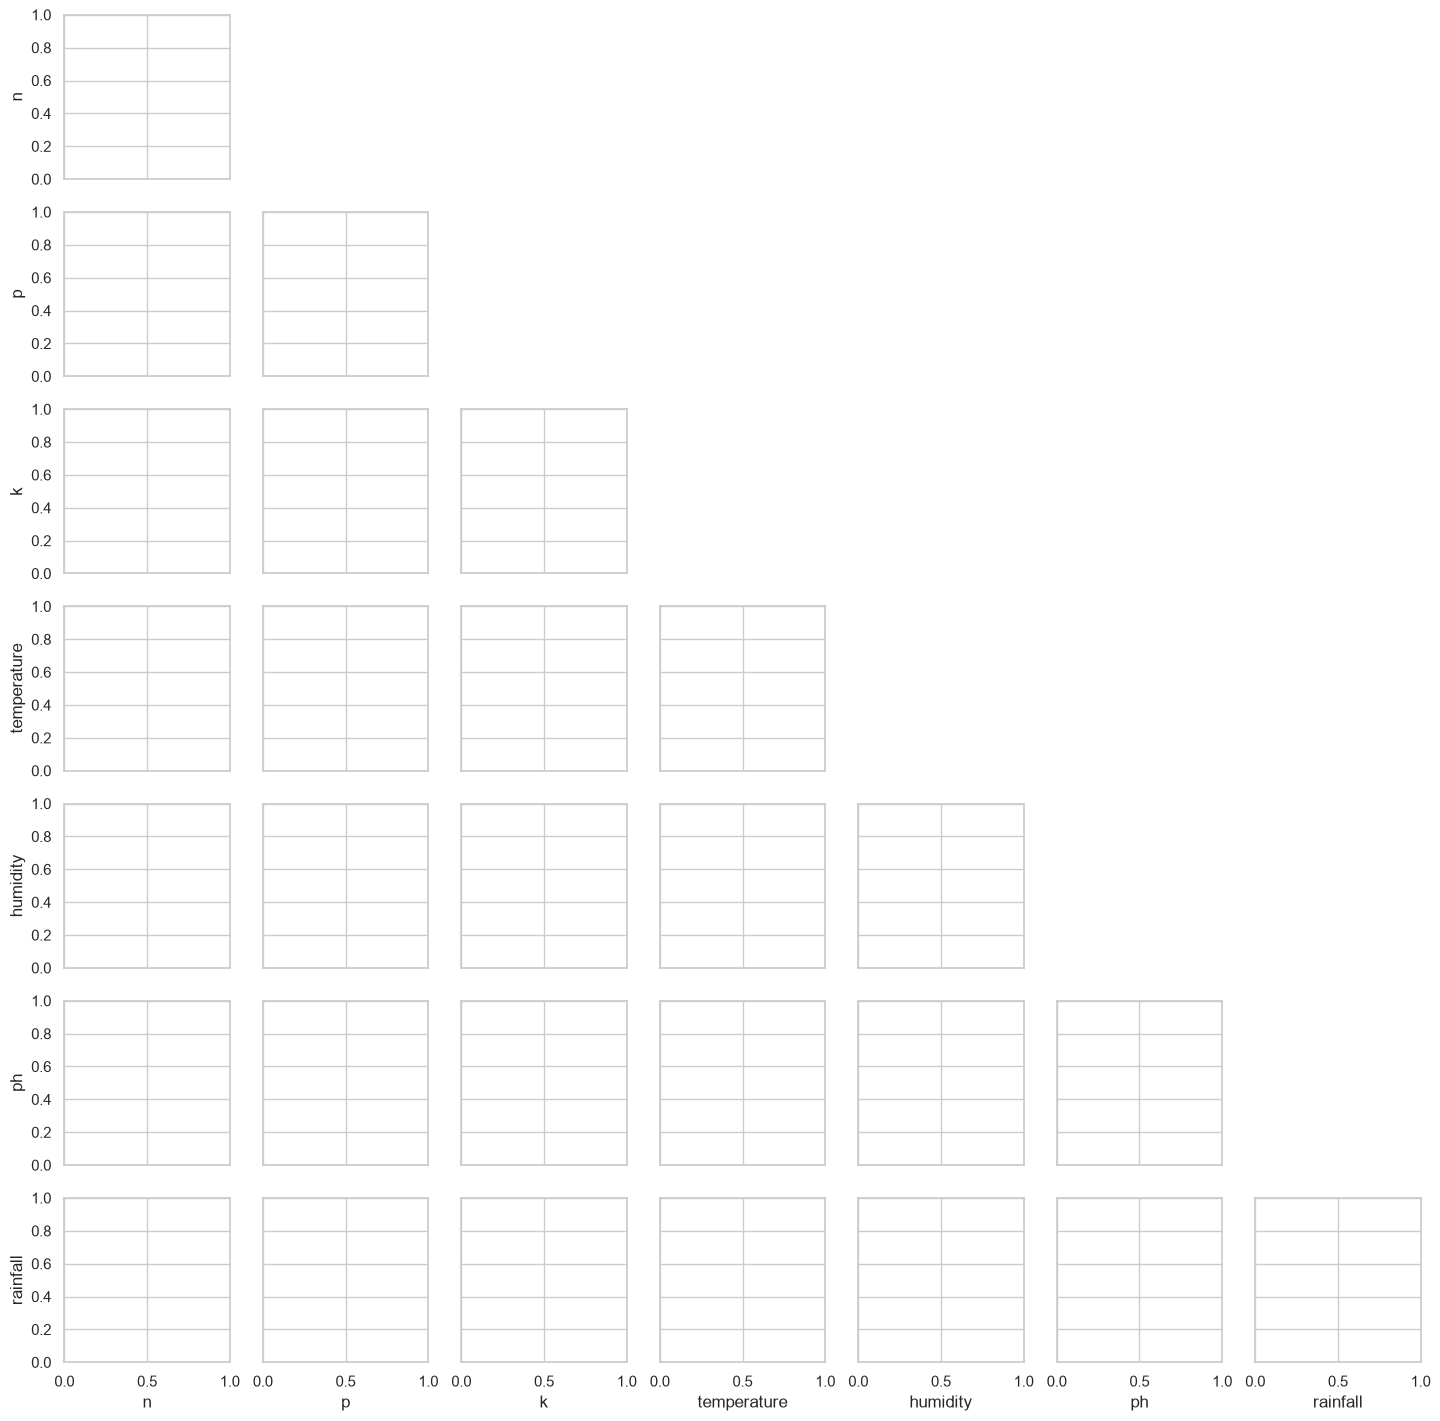

In [31]:
sample_df = df.groupby(target_col, group_keys=False).apply(lambda x: x.sample(20, random_state=42))

sns.pairplot(
    sample_df,
    vars=feature_cols,
    hue=target_col,
    corner=True,
    plot_kws={"alpha": 0.7, "s": 25}
)
plt.show()

The pairplot gives a preliminary view of class separability across feature pairs. Some crop groups appear separable based on combinations of rainfall, humidity, potassium, and temperature, while others overlap more strongly.

In [32]:
X = df[feature_cols]
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df[target_col] = y.values
pca.explained_variance_ratio_

array([0.27588831, 0.18484431])

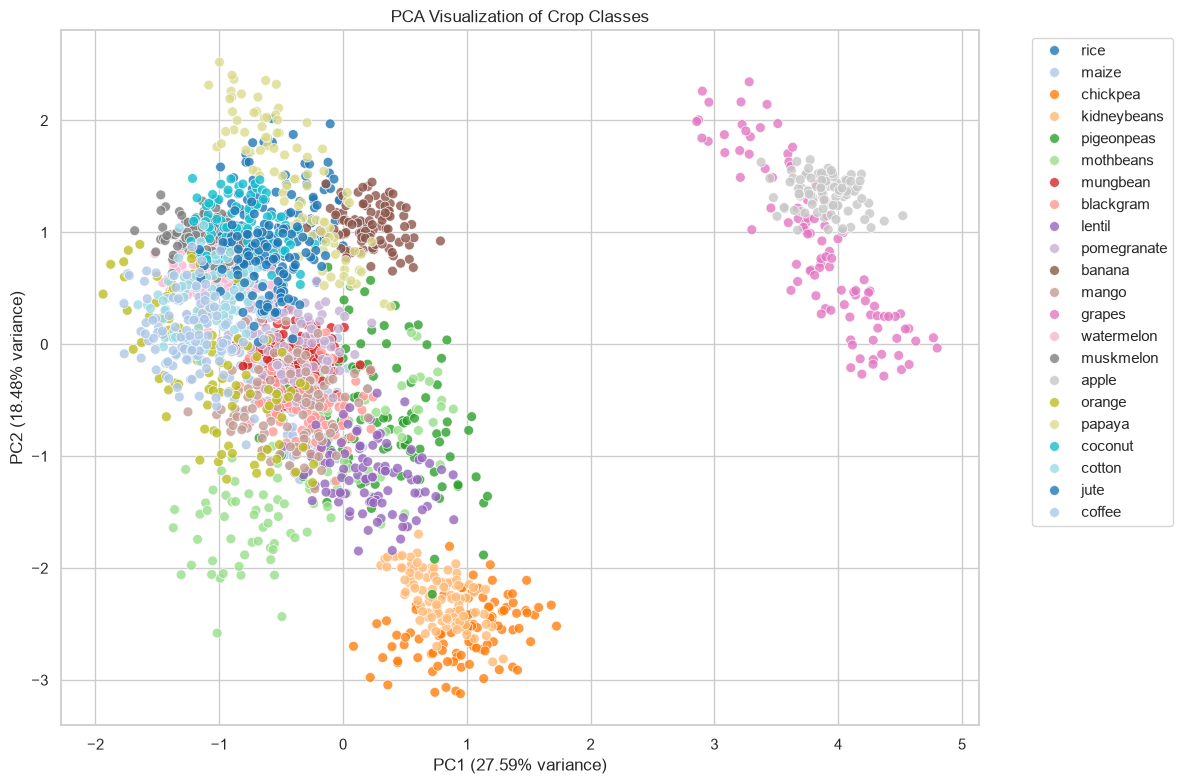

In [33]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=target_col,
    palette="tab20",
    alpha=0.8,
    s=50
)
plt.title("PCA Visualization of Crop Classes")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The PCA plot projects the seven-dimensional feature space into two dimensions. Some crop classes show clear separation, while others overlap. This indicates that the classification task benefits from using the full multidimensional feature set rather than relying on only two principal components.

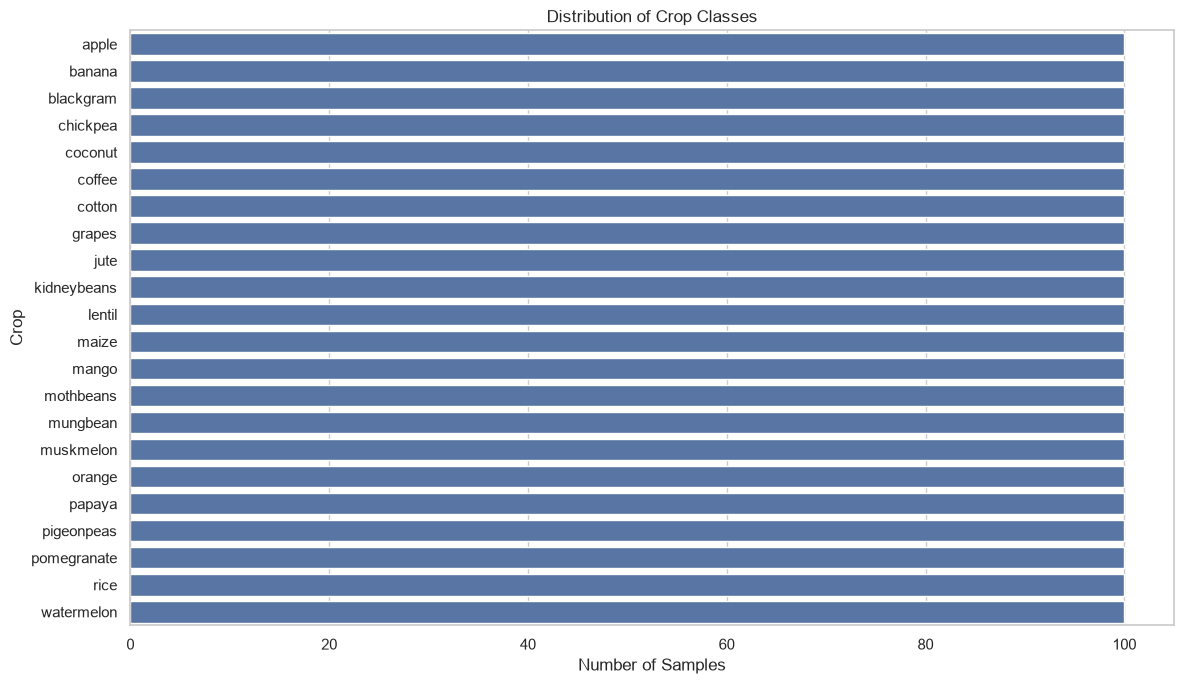

In [34]:
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df,
    y=target_col,
    order=crop_counts.index
)
plt.title("Distribution of Crop Classes")
plt.xlabel("Number of Samples")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig("../reports/figures/crop_class_distribution.png", dpi=300)
plt.show()

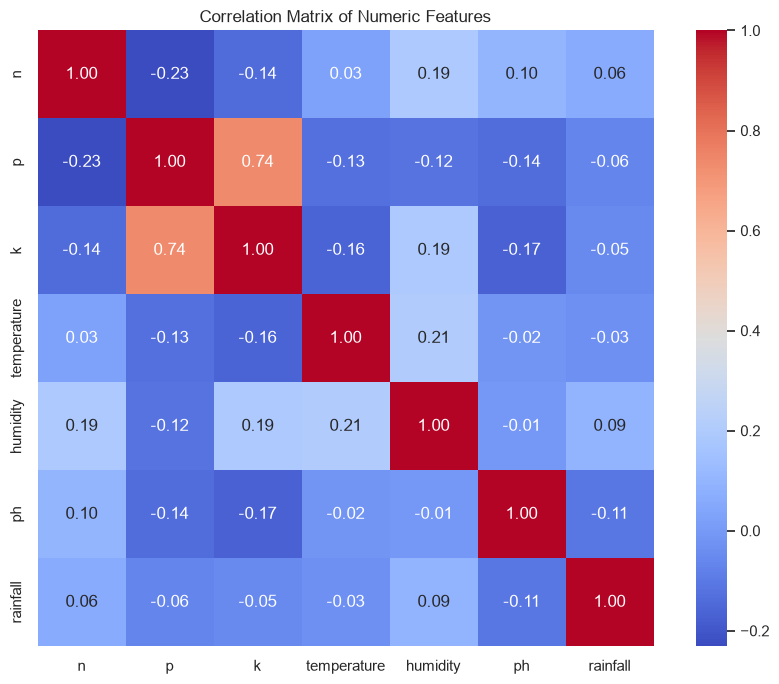

In [35]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=300)
plt.show()

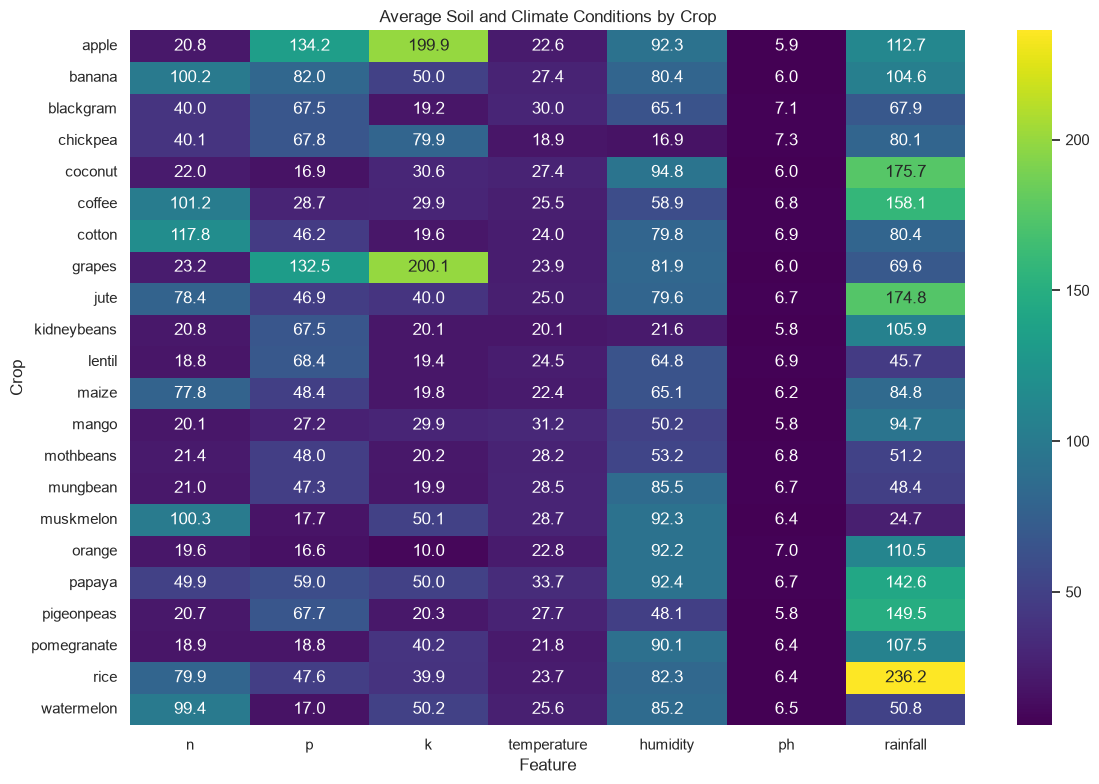

In [36]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    crop_feature_means,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)
plt.title("Average Soil and Climate Conditions by Crop")
plt.xlabel("Feature")
plt.ylabel("Crop")
plt.tight_layout()
plt.savefig("../reports/figures/crop_feature_profile_heatmap.png", dpi=300)
plt.show()

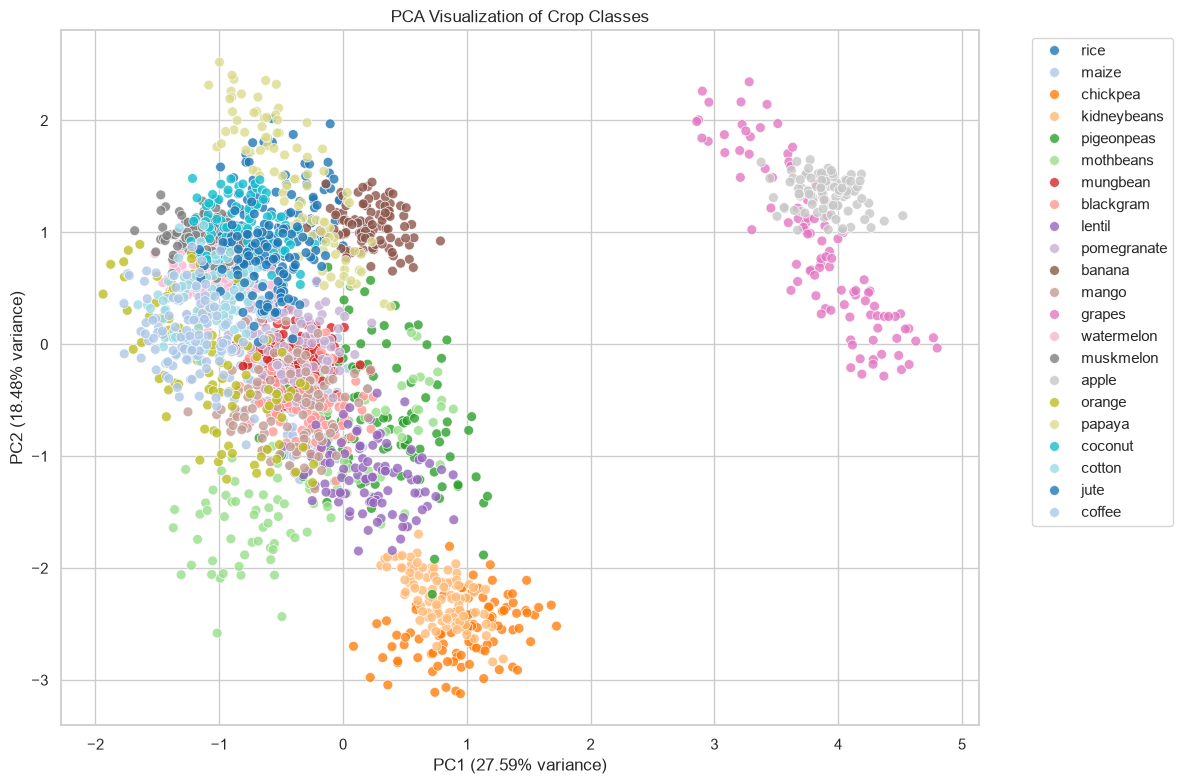

In [37]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue=target_col,
    palette="tab20",
    alpha=0.8,
    s=50
)
plt.title("PCA Visualization of Crop Classes")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/pca_crop_classes.png", dpi=300)
plt.show()

## EDA Summary

The crop recommendation dataset contains 2,200 observations across 22 balanced crop classes. Each crop has 100 observations, meaning the target distribution is perfectly balanced.

The seven input features represent soil macronutrients and climate-related variables: nitrogen, phosphorus, potassium, temperature, humidity, pH, and rainfall. The features have different ranges and distributions, so scaling will be important for models that are sensitive to feature magnitude.

Crop-wise boxplots and heatmaps show that different crops are associated with distinct soil and climate profiles. Rainfall, humidity, potassium, and nutrient levels appear especially useful for distinguishing several crops.

The PCA visualization shows partial class separation in two dimensions, but some crop classes still overlap. This suggests that the full seven-dimensional feature space is likely needed for strong classification performance.

Overall, the EDA supports the use of supervised multi-class classification models for crop recommendation.